In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
import os

print(os.getcwd())

/Users/kv/predictive analytics project


In [11]:
data = pd.read_csv('dataset/sales.csv')

data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
# Remove missing values
data = data.dropna()

# Remove duplicates
data = data.drop_duplicates()

print(data.shape)

(9994, 21)


In [13]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [14]:
monthly_sales = data.groupby(
    data['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales = monthly_sales.reset_index()

monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)

print(monthly_sales.head())

  Order Date      Sales
0    2014-01  14236.895
1    2014-02   4519.892
2    2014-03  55691.009
3    2014-04  28295.345
4    2014-05  23648.287


In [15]:
monthly_sales['Month_Number'] = range(len(monthly_sales))

In [16]:
X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
predictions = model.predict(X_test)

print(predictions[:5])

[55587.34412875 68462.31457329 54596.96178686 71433.46159895
 52616.19710309]


In [20]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 20460.74244429802
R2 Score: -1.630512243911367


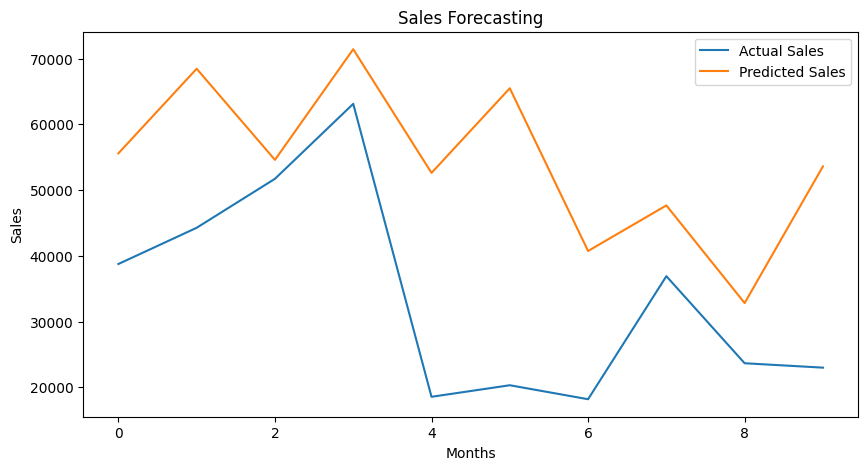

In [21]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual Sales')
plt.plot(predictions, label='Predicted Sales')

plt.title('Sales Forecasting')
plt.xlabel('Months')
plt.ylabel('Sales')

plt.legend()

plt.show()

In [22]:
future_months = [[36], [37], [38], [39], [40]]

future_predictions = model.predict(future_months)

print(future_predictions)

[64500.78520574 65491.16754763 66481.54988951 67471.9322314
 68462.31457329]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
